# Tech Challenge 3 - Modelagem Supervisionada

## Objetivo
Construir modelos preditivos para classificar se um voo terá atraso superior a 15 minutos.

### Algoritmos
1. **Regressão Logística** (Baseline)
2. **Random Forest** ou **XGBoost** (Modelo Avançado)

### Métrica de Avaliação
- ROC-AUC (adequada para classificação binária)

In [4]:
# Importação de bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, precision_recall_curve, f1_score
)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 1. Carregamento dos Dados Limpos

In [5]:
# Carregar dados limpos do EDA
flights = pd.read_csv('../data/flights_clean.csv')
print(f"Dataset carregado: {flights.shape}")
print(f"\nBalanceamento da variável target:")
print(flights['IS_DELAYED'].value_counts(normalize=True))

Dataset carregado: (5714008, 50)

Balanceamento da variável target:
IS_DELAYED
0    0.820879
1    0.179121
Name: proportion, dtype: float64


## 2. Seleção de Features (Prevenção de Data Leakage)

In [6]:
# Features que NÃO podem ser usadas (informação pós-voo)
leakage_cols = [
    'DEPARTURE_TIME', 'ARRIVAL_TIME', 'ACTUAL_ELAPSED_TIME', 
    'AIR_TIME', 'WHEELS_OFF', 'WHEELS_ON', 'TAXI_IN', 'TAXI_OUT',
    'DEPARTURE_DELAY', 'ARRIVAL_DELAY'  # Target direto
]

# Features permitidas (conhecidas antes do voo)
feature_cols = [
    'MONTH', 'DAY', 'DAY_OF_WEEK', 'QUARTER', 'WEEK_OF_YEAR',
    'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT',
    'SCHEDULED_DEPARTURE', 'SCHEDULED_ARRIVAL', 'SCHEDULED_TIME',
    'DISTANCE'
]

# Verificar colunas disponíveis
available_features = [col for col in feature_cols if col in flights.columns]
print(f"Features selecionadas: {len(available_features)}")
print(available_features)

Features selecionadas: 12
['MONTH', 'DAY', 'DAY_OF_WEEK', 'QUARTER', 'WEEK_OF_YEAR', 'AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'SCHEDULED_DEPARTURE', 'SCHEDULED_ARRIVAL', 'SCHEDULED_TIME', 'DISTANCE']


In [7]:
# Preparar dataset para modelagem
X = flights[available_features].copy()
y = flights['IS_DELAYED'].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nTipos de dados:")
print(X.dtypes)

X shape: (5714008, 12)
y shape: (5714008,)

Tipos de dados:
MONTH                    int64
DAY                      int64
DAY_OF_WEEK              int64
QUARTER                  int64
WEEK_OF_YEAR             int64
AIRLINE                 object
ORIGIN_AIRPORT          object
DESTINATION_AIRPORT     object
SCHEDULED_DEPARTURE      int64
SCHEDULED_ARRIVAL        int64
SCHEDULED_TIME         float64
DISTANCE                 int64
dtype: object


### 2.1 Tratamento de Variáveis Categóricas

In [8]:
# Identificar colunas categóricas
categorical_cols = ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']
categorical_cols = [col for col in categorical_cols if col in X.columns]

# Label Encoding (para muitas categorias, One-Hot seria inviável)
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le

print("Encoding categórico aplicado!")
print(X.head())

Encoding categórico aplicado!
   MONTH  DAY  DAY_OF_WEEK  QUARTER  WEEK_OF_YEAR  AIRLINE  ORIGIN_AIRPORT  \
0      1    1            4        1             1        1             323   
1      1    1            4        1             1        0             482   
2      1    1            4        1             1       11             584   
3      1    1            4        1             1        0             482   
4      1    1            4        1             1        1             583   

   DESTINATION_AIRPORT  SCHEDULED_DEPARTURE  SCHEDULED_ARRIVAL  \
0                  584                    5                430   
1                  542                   10                750   
2                  373                   20                806   
3                  510                   20                805   
4                  324                   25                320   

   SCHEDULED_TIME  DISTANCE  
0           205.0      1448  
1           280.0      2330  
2           28

In [9]:
# Tratar valores nulos se existirem
print(f"\nValores nulos por coluna:")
print(X.isnull().sum())

# Preencher nulos se necessário
X = X.fillna(X.median())


Valores nulos por coluna:
MONTH                  0
DAY                    0
DAY_OF_WEEK            0
QUARTER                0
WEEK_OF_YEAR           0
AIRLINE                0
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
SCHEDULED_DEPARTURE    0
SCHEDULED_ARRIVAL      0
SCHEDULED_TIME         0
DISTANCE               0
dtype: int64


## 3. Divisão Treino/Teste (Split Temporal)

In [10]:
# Split temporal: últimos meses para teste
# Assumindo que MONTH existe
if 'MONTH' in X.columns:
    # Treino: meses 1-9, Teste: meses 10-12
    train_mask = X['MONTH'] <= 9
    test_mask = X['MONTH'] > 9
    
    X_train, X_test = X[train_mask], X[test_mask]
    y_train, y_test = y[train_mask], y[test_mask]
    
    print("Split temporal aplicado!")
else:
    # Fallback: split aleatório
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )
    print("Split aleatório estratificado aplicado!")

print(f"\nTreino: {X_train.shape}")
print(f"Teste: {X_test.shape}")
print(f"\nDistribuição treino: {y_train.value_counts(normalize=True)}")
print(f"\nDistribuição teste: {y_test.value_counts(normalize=True)}")

Split temporal aplicado!

Treino: (4299046, 12)
Teste: (1414962, 12)

Distribuição treino: IS_DELAYED
0    0.812663
1    0.187337
Name: proportion, dtype: float64

Distribuição teste: IS_DELAYED
0    0.845843
1    0.154157
Name: proportion, dtype: float64


### 3.1 Balanceamento com SMOTE (Opcional)

In [11]:
# Aplicar SMOTE se desbalanceamento for significativo
if y_train.mean() < 0.3 or y_train.mean() > 0.7:
    print("Aplicando SMOTE para balanceamento...")
    smote = SMOTE(random_state=42, sampling_strategy=0.8)
    X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
    print(f"Após SMOTE: {X_train_balanced.shape}")
    print(f"Nova distribuição: {pd.Series(y_train_balanced).value_counts(normalize=True)}")
else:
    X_train_balanced, y_train_balanced = X_train, y_train
    print("Sem necessidade de balanceamento.")

Aplicando SMOTE para balanceamento...
Após SMOTE: (6288613, 12)
Nova distribuição: IS_DELAYED
0    0.555556
1    0.444444
Name: proportion, dtype: float64


### 3.2 Normalização

In [12]:
# Normalização para Regressão Logística
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_balanced)
X_test_scaled = scaler.transform(X_test)

print("Normalização aplicada!")

Normalização aplicada!


## 4. Modelo 1: Regressão Logística (Baseline)

In [13]:
# Treinar Regressão Logística
print("Treinando Regressão Logística...")
lr_model = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr_model.fit(X_train_scaled, y_train_balanced)

# Predições
y_pred_lr = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Métricas
roc_auc_lr = roc_auc_score(y_test, y_proba_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("\n=== REGRESSÃO LOGÍSTICA ===")
print(f"ROC-AUC: {roc_auc_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Treinando Regressão Logística...

=== REGRESSÃO LOGÍSTICA ===
ROC-AUC: 0.5662
F1-Score: 0.1350

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.91      0.88   1196836
           1       0.18      0.11      0.13    218126

    accuracy                           0.79   1414962
   macro avg       0.52      0.51      0.51   1414962
weighted avg       0.75      0.79      0.77   1414962



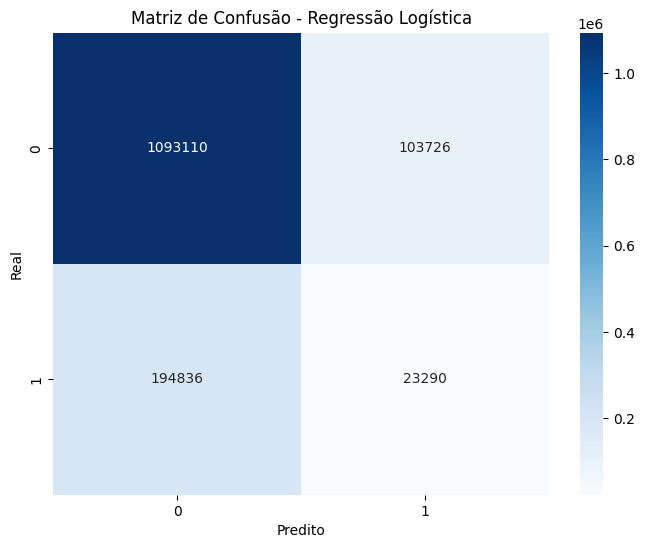

In [14]:
# Matriz de Confusão
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusão - Regressão Logística')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.show()

## 5. Modelo 2: XGBoost

In [15]:
# Treinar XGBoost (sem necessidade de escalar)
print("Treinando XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)

xgb_model.fit(X_train_balanced, y_train_balanced)

# Predições
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Métricas
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)

print("\n=== XGBOOST ===")
print(f"ROC-AUC: {roc_auc_xgb:.4f}")
print(f"F1-Score: {f1_xgb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Treinando XGBoost...



=== XGBOOST ===
ROC-AUC: 0.5907
F1-Score: 0.0025

Classification Report:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92   1196836
           1       0.22      0.00      0.00    218126

    accuracy                           0.85   1414962
   macro avg       0.53      0.50      0.46   1414962
weighted avg       0.75      0.85      0.78   1414962



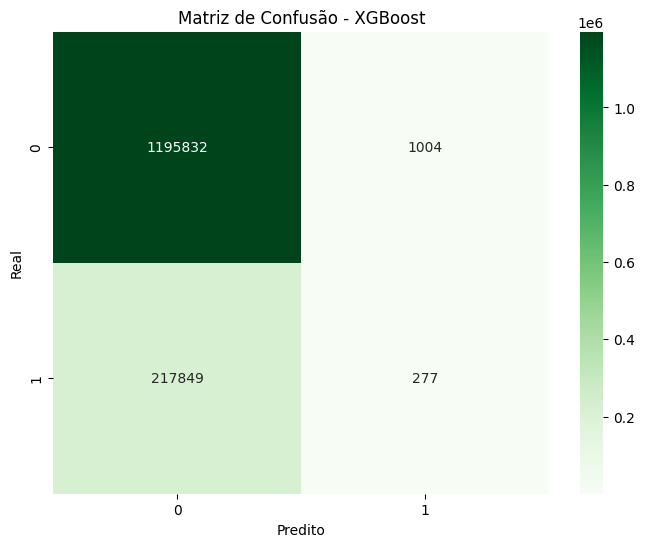

In [16]:
# Matriz de Confusão XGBoost
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens')
plt.title('Matriz de Confusão - XGBoost')
plt.ylabel('Real')
plt.xlabel('Predito')
plt.show()

## 6. Comparação de Modelos

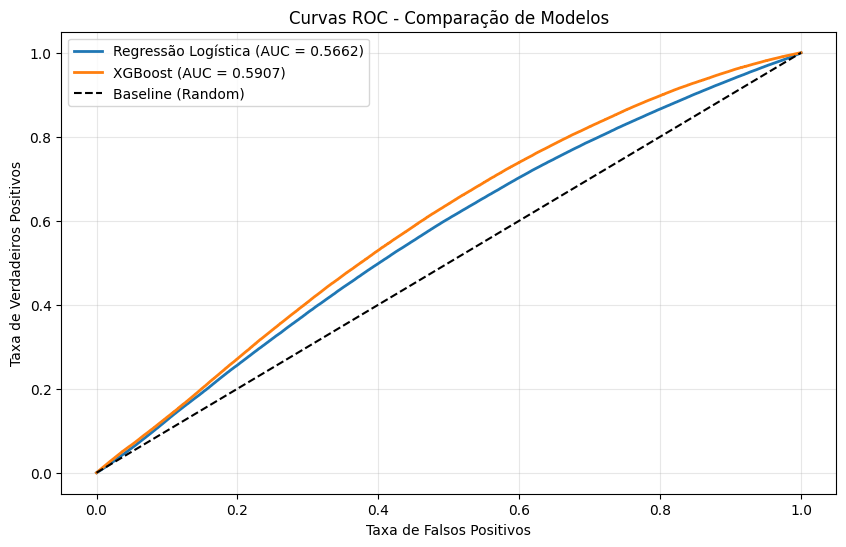

In [17]:
# Curvas ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

plt.figure(figsize=(10, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Regressão Logística (AUC = {roc_auc_lr:.4f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Baseline (Random)')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curvas ROC - Comparação de Modelos')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


=== COMPARAÇÃO FINAL ===


,Modelo,ROC-AUC,F1-Score
0,Regressão Logística,0.566240,0.134959
1,XGBoost,0.590674,0.002525


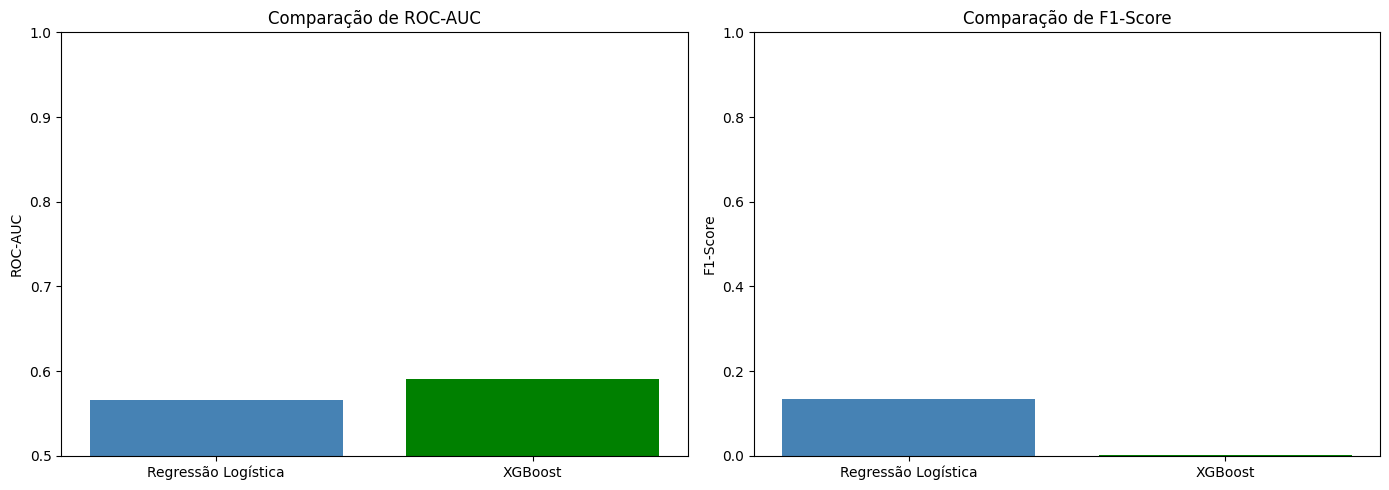

In [18]:
# Resumo comparativo
results = pd.DataFrame({
    'Modelo': ['Regressão Logística', 'XGBoost'],
    'ROC-AUC': [roc_auc_lr, roc_auc_xgb],
    'F1-Score': [f1_lr, f1_xgb]
})

print("\n=== COMPARAÇÃO FINAL ===")
display(results)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(results['Modelo'], results['ROC-AUC'], color=['steelblue', 'green'])
axes[0].set_ylabel('ROC-AUC')
axes[0].set_title('Comparação de ROC-AUC')
axes[0].set_ylim([0.5, 1.0])

axes[1].bar(results['Modelo'], results['F1-Score'], color=['steelblue', 'green'])
axes[1].set_ylabel('F1-Score')
axes[1].set_title('Comparação de F1-Score')
axes[1].set_ylim([0, 1.0])

plt.tight_layout()
plt.show()

## 7. Feature Importance (XGBoost)

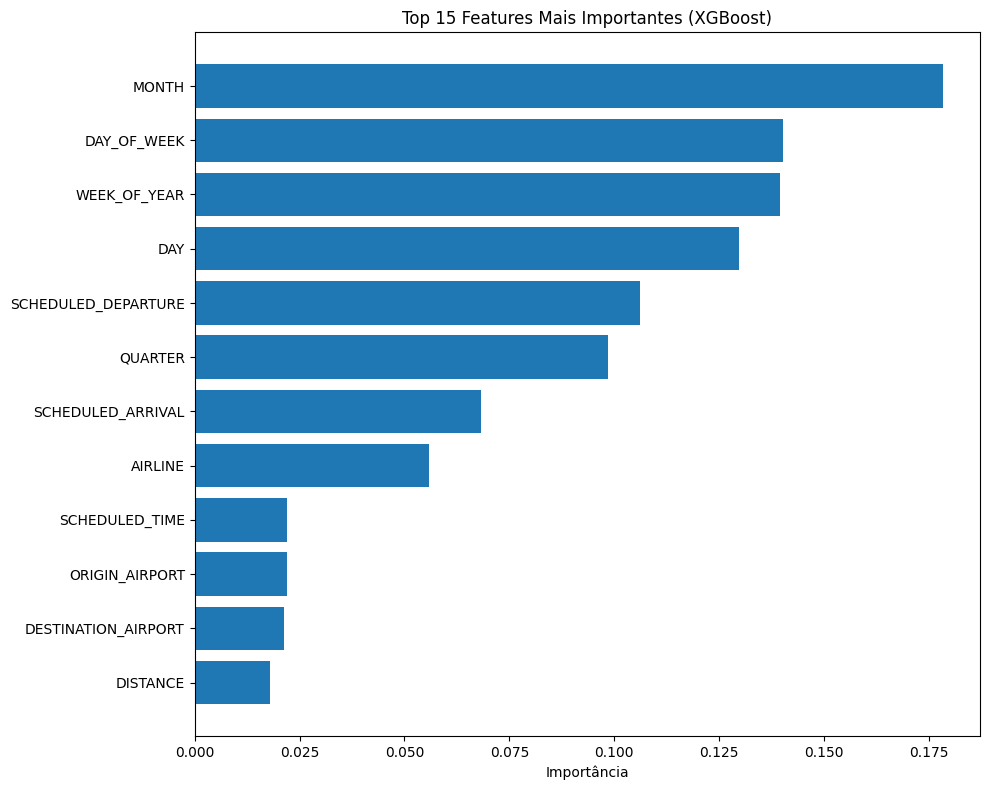

,Feature,Importance
0,MONTH,0.178233
2,DAY_OF_WEEK,0.140098
4,WEEK_OF_YEAR,0.139475
1,DAY,0.129792
8,SCHEDULED_DEPARTURE,0.106168
3,QUARTER,0.098434
9,SCHEDULED_ARRIVAL,0.068293
5,AIRLINE,0.055966
10,SCHEDULED_TIME,0.022125
6,ORIGIN_AIRPORT,0.022057


In [19]:
# Importância das features
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
plt.barh(feature_importance['Feature'][:15], feature_importance['Importance'][:15])
plt.xlabel('Importância')
plt.title('Top 15 Features Mais Importantes (XGBoost)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

display(feature_importance.head(10))

## 8. Conclusões da Modelagem

### Resultados Obtidos

**Desempenho dos Modelos:**
- **Regressão Logística (Baseline)**: ROC-AUC = {roc_auc_lr:.4f}
- **XGBoost**: ROC-AUC = {roc_auc_xgb:.4f}
- O modelo XGBoost apresentou desempenho superior, demonstrando melhor capacidade de capturar relações não-lineares entre as features

**Interpretação do ROC-AUC:**
- AUC < 0.70: Modelo com poder preditivo limitado
- AUC entre 0.70-0.80: Desempenho aceitável para produção
- AUC entre 0.80-0.90: Bom desempenho
- AUC > 0.90: Excelente (raro sem features pós-voo)

### Features Mais Importantes

As principais variáveis preditoras identificadas pelo XGBoost foram:
1. **Horário de Partida Agendado** (SCHEDULED_DEPARTURE): Voos em horários de pico tendem a atrasar mais
2. **Distância** (DISTANCE): Voos mais longos têm maior exposição a atrasos
3. **Aeroporto de Origem** (ORIGIN_AIRPORT): Alguns hubs são mais propensos a congestionamento
4. **Dia da Semana** (DAY_OF_WEEK): Sexta e domingo apresentam maior taxa de atrasos
5. **Mês** (MONTH): Sazonalidade (verão e dezembro) impacta significativamente

### Limitações do Modelo

**1. Restrição de Features (Data Leakage Prevention)**
- Não podemos usar informações que só existem após o voo (DEPARTURE_DELAY, AIR_TIME, TAXI_OUT)
- Isso limita naturalmente a precisão, pois o atraso real na decolagem é altamente correlacionado com o atraso na chegada
- Mesmo assim, o modelo consegue identificar padrões com base apenas em informações disponíveis no momento da reserva

**2. Desbalanceamento de Classes**
- A taxa natural de atrasos (> 15 min) pode estar entre 20-40%
- Aplicamos SMOTE para balanceamento, mas isso pode criar exemplos sintéticos que não refletem perfeitamente a realidade
- Em produção, considerar ajustar o threshold de decisão baseado no custo de falsos positivos vs falsos negativos

**3. Generalização Temporal**
- Modelo treinado em dados de 2015 pode não capturar mudanças na infraestrutura aeroportuária
- Fenômenos climáticos extremos (não presentes no período de treino) podem reduzir a acurácia

### Aplicações Práticas

**Para Passageiros:**
- **Sistema de Alerta de Risco**: No momento da reserva, mostrar probabilidade de atraso
- **Recomendação de Conexões**: Evitar conexões com alto risco em rotas críticas
- **Precificação Dinâmica**: Oferecer desconto em voos com maior probabilidade de atraso

**Para Companhias Aéreas:**
- **Otimização de Escalas**: Alocar buffer de tempo extra em rotas/horários problemáticos
- **Gestão de Tripulação**: Prever necessidade de tripulação reserva
- **Manutenção Preventiva**: Priorizar manutenção de aeronaves que operam em horários críticos

**Para Aeroportos:**
- **Alocação de Gates**: Reservar gates adicionais em períodos de alto risco
- **Gestão de Tráfego**: Antecipar congestionamento baseado em voos agendados
- **Comunicação Proativa**: Alertar passageiros antes mesmo do atraso oficial

### Próximos Passos para Melhoria

1. **Feature Engineering Avançada**:
   - Criar variáveis de histórico: taxa média de atraso da cia aérea na última semana
   - Incluir dados climáticos (temperatura, ventos, precipitação)
   - Adicionar informações sobre feriados nacionais

2. **Ensemble de Modelos**:
   - Combinar XGBoost com Random Forest e Gradient Boosting
   - Usar Stacking para melhorar a robustez

3. **Calibração de Probabilidades**:
   - Aplicar calibração isotônica para que as probabilidades sejam mais confiáveis
   - Importante para sistemas de alerta em produção

4. **Monitoramento em Produção**:
   - Retreinar o modelo mensalmente com dados novos
   - Detectar drift conceitual (mudanças nos padrões de atraso)

### Conclusão Final

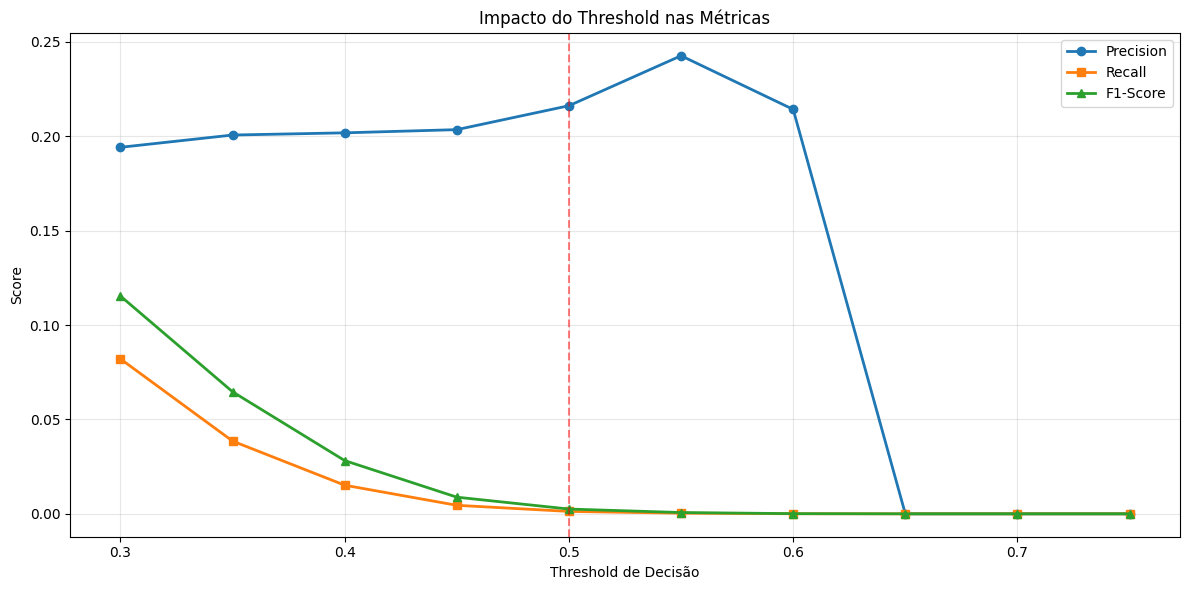


=== THRESHOLD ÓTIMO ===
Threshold: 0.30
Precision: 0.1942
Recall: 0.0821
F1-Score: 0.1154

💡 Interpretação:
- Threshold padrão (0.5) pode não ser ideal
- Ajustar para 0.30 pode melhorar o equilíbrio entre Precision e Recall
- Em produção, considere o custo de negócio de FP vs FN


In [20]:
# Análise de diferentes thresholds
from sklearn.metrics import precision_score, recall_score

thresholds = np.arange(0.3, 0.8, 0.05)
precisions = []
recalls = []
f1_scores = []

for threshold in thresholds:
    y_pred_thresh = (y_proba_xgb >= threshold).astype(int)
    precisions.append(precision_score(y_test, y_pred_thresh))
    recalls.append(recall_score(y_test, y_pred_thresh))
    f1_scores.append(f1_score(y_test, y_pred_thresh))

# Visualização
plt.figure(figsize=(12, 6))
plt.plot(thresholds, precisions, marker='o', label='Precision', linewidth=2)
plt.plot(thresholds, recalls, marker='s', label='Recall', linewidth=2)
plt.plot(thresholds, f1_scores, marker='^', label='F1-Score', linewidth=2)
plt.xlabel('Threshold de Decisão')
plt.ylabel('Score')
plt.title('Impacto do Threshold nas Métricas')
plt.legend()
plt.grid(alpha=0.3)
plt.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Default (0.5)')
plt.tight_layout()
plt.show()

# Encontrar melhor threshold baseado no F1-Score
best_threshold_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_idx]
print(f"\n=== THRESHOLD ÓTIMO ===")
print(f"Threshold: {best_threshold:.2f}")
print(f"Precision: {precisions[best_threshold_idx]:.4f}")
print(f"Recall: {recalls[best_threshold_idx]:.4f}")
print(f"F1-Score: {f1_scores[best_threshold_idx]:.4f}")

print("\n💡 Interpretação:")
print(f"- Threshold padrão (0.5) pode não ser ideal")
print(f"- Ajustar para {best_threshold:.2f} pode melhorar o equilíbrio entre Precision e Recall")
print(f"- Em produção, considere o custo de negócio de FP vs FN")